# Session 2 (Day 1 — Afternoon)
## Wrangling Financial Time Series
**Enhancing Data Analysis Skills for Informed Investment Insights**

---

> **Guiding question:** *"How do I know the data is telling the truth before I draw conclusions from it?"*

---

## Learning objectives

By the end of this session you will be able to:

- **Identify** the three main missing-data strategies (forward-fill, drop, interpolate) and explain when each is appropriate
- **Explain** the daily-vs-monthly frequency mismatch between equity prices and macro indicators — and resolve it using resampling
- **Compute** simple percentage returns and log returns from a price series — and explain why log returns are preferred for statistical analysis
- **Build** a rolling volatility series and a cumulative return index, and interpret what they tell you about the portfolio
- **Construct** the monthly returns matrix that will serve as the single input to all portfolio analytics in Day 2

> **Note:** This notebook re-downloads all data fresh from Yahoo Finance and FRED. No files from Session 1 are needed.


## Why we re-download the data

Each notebook in this seminar is **self-contained** — it downloads everything it needs from scratch, right at the start.

**Why not just read the CSV files saved in Session 1?**

- The data is small (8 tickers, ~750 daily rows) and downloads in under 30 seconds
- Re-downloading means the data is always current — no stale files to worry about
- You can run any session independently, in any order, without needing to track which files were saved where
- It eliminates a whole class of errors: "which CSV file did I save last week?", "is this the latest version?"

This pattern — **download fresh, process, analyse, optionally save** — is a best practice in data-driven investment workflows. You will see it in every notebook in this series.


In [ ]:
# ── INSTALL AND IMPORT ────────────────────────────────────────────────────────
# Install the external libraries needed for this session.
# --quiet suppresses verbose installation output.

!pip install yfinance --quiet    # yfinance: downloads price data from Yahoo Finance
!pip install fredapi --quiet     # fredapi:  downloads macro data from the Federal Reserve

print('Libraries installed.')
print()

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
# Same imports as Session 1, plus numpy and seaborn.

import pandas as pd
# pandas: the core data library. Provides DataFrame and time-series tools.
# Analogy: Excel worksheets + all their formulas, built into Python.

import numpy as np
# numpy: numerical computing library. Provides mathematical functions (log, sqrt, etc.).
# Analogy: the mathematics engine behind Excel's formula engine — but accessible as functions.

import yfinance as yf
# yfinance: connects to Yahoo Finance for price history.
# Analogy: a free, automated version of a Bloomberg BDH() data pull.

from fredapi import Fred
# Fred: the connection class to the Federal Reserve Economic Data database.
# Analogy: a terminal session to a central bank data service.

import matplotlib.pyplot as plt
# matplotlib: the standard Python charting library.
# Analogy: Excel's chart tools, but with full programmatic control.

import seaborn as sns
# seaborn: a higher-level charting library built on top of matplotlib.
# Provides additional chart types — we use it here for the missing-data heatmap.
# Analogy: like a premium charting add-in for Excel (cleaner aesthetics by default).

from datetime import date
# date: Python's calendar date object.
# Analogy: Excel's TODAY() and DATE() functions — provides date arithmetic.

print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
# ── RE-DOWNLOAD EQUITY PRICES FROM YAHOO FINANCE ─────────────────────────────
# This is identical to Session 1. Running it again ensures this notebook is
# fully self-contained and always uses the most current data.

# Define the GIS model portfolio tickers (same list as Session 1)
TICKERS = [
    'AAPL',   # US large-cap equity — Apple Inc
    'MSFT',   # US large-cap equity — Microsoft Corporation
    'JPM',    # US financials equity — JPMorgan Chase
    'XOM',    # US energy equity — Exxon Mobil
    'JNJ',    # US healthcare equity — Johnson & Johnson
    'GLD',    # Commodities — SPDR Gold Shares ETF
    '^GSPC',  # Benchmark only — S&P 500 Index (NOT a portfolio holding)
    'IEF',    # Fixed income — iShares 7-10 Year Treasury Bond ETF
]

# Set the 5-year download window
end_date   = date.today()
start_date = date(
    end_date.year - 5,
    end_date.month,
    end_date.day,
)

print(f'Download window: {start_date}  ->  {end_date}')
print(f'Tickers: {TICKERS}')
print()

# Download adjusted close prices from Yahoo Finance
raw_data = yf.download(
    tickers     = TICKERS,
    start       = start_date,
    end         = end_date,
    auto_adjust = True,   # adjust for splits and dividends
    progress    = True,   # show a download progress bar
)

# Extract only the 'Close' column (= adjusted close when auto_adjust=True)
prices = raw_data['Close']

print()
print(f'Download complete. Shape: {prices.shape[0]} rows x {prices.shape[1]} columns')
print(f'({prices.shape[0]} trading days x {prices.shape[1]} assets)')

Download window: 2021-04-08  ->  2026-04-08
Tickers: ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'GLD', '^GSPC', 'IEF']



[*********************100%***********************]  8 of 8 completed


Download complete. Shape: 1255 rows x 8 columns
(1255 trading days x 8 assets)


In [ ]:
# ── RE-DOWNLOAD CPI FROM FRED ─────────────────────────────────────────────────
# For this session we need only the CPI series to demonstrate frequency alignment.
# (All five macro series are downloaded in Session 1 — here we keep the download minimal.)

# ← CHANGE ME ─────────────────────────────────────────────────────────────────
# Paste your FRED API key here (the same key from Session 1).
# Instructions for getting a free key: https://fred.stlouisfed.org -> My Account -> API Keys

FRED_API_KEY = 'YOUR_FRED_API_KEY'   # <- paste your 32-character key here

# Create the FRED client object — opens a connection to the FRED database
fred = Fred(api_key=FRED_API_KEY)

# Download the Consumer Price Index (monthly series)
# This is the headline inflation measure published by the US Bureau of Labor Statistics
cpi = fred.get_series(
    'CPIAUCSL',                    # FRED series ID for CPI
    observation_start = start_date,
    observation_end   = end_date,
)
cpi.name = 'CPI'   # label the Series for use as a column name later

print(f'CPI downloaded: {len(cpi)} monthly observations')
print(f'Date range: {cpi.index[0].date()}  ->  {cpi.index[-1].date()}')
print()
print('Note: CPI has only ~36 rows over 3 years (monthly frequency).')
print('      Equity prices have ~756 rows (daily frequency).')
print('      We will resolve this mismatch in Section 2 of this notebook.')

---

# Section 1 — The Anatomy of a Messy Financial Dataset

## Why financial data is always imperfect

No financial dataset arrives clean and ready to analyse. Every practitioner — whether they use Bloomberg, FactSet, or a Python API — encounters the same problems:

| Problem | Example | Consequence if ignored |
|---|---|---|
| **Market holidays** | NYSE is closed on US public holidays — no price for that date | Missing rows create gaps; return calculations span the wrong period |
| **Corporate actions** | A 2-for-1 stock split halves the price overnight | A fake -50% return on the split date inflates volatility and biases all statistics |
| **Dividend ex-dates** | The price drops by the dividend amount on the ex-dividend date | Same as above — creates phantom returns unless adjustments are made |
| **Delistings** | A company is acquired or goes bankrupt — no more prices | Survivorship bias: your dataset only contains companies that survived |
| **Reporting lags** | CPI is published ~2 weeks after the reference month ends | Analysis may use data that was not yet available in real time |
| **API timing quirks** | The last row in a download may be a partial day (market still open) | The "latest" price may be stale or intraday |

**This is not a Python problem.** Every Bloomberg user faces exactly these issues — Python just makes them visible (and fixable) programmatically rather than requiring manual inspection of a spreadsheet.

The next three cells demonstrate the three standard strategies for handling missing data in a financial context.


=== MISSING DATA SUMMARY ===


,Missing Days,Missing (%)
Ticker,,
AAPL,0,0.0
GLD,0,0.0
IEF,0,0.0
JNJ,0,0.0
JPM,0,0.0
MSFT,0,0.0
XOM,0,0.0
^GSPC,0,0.0


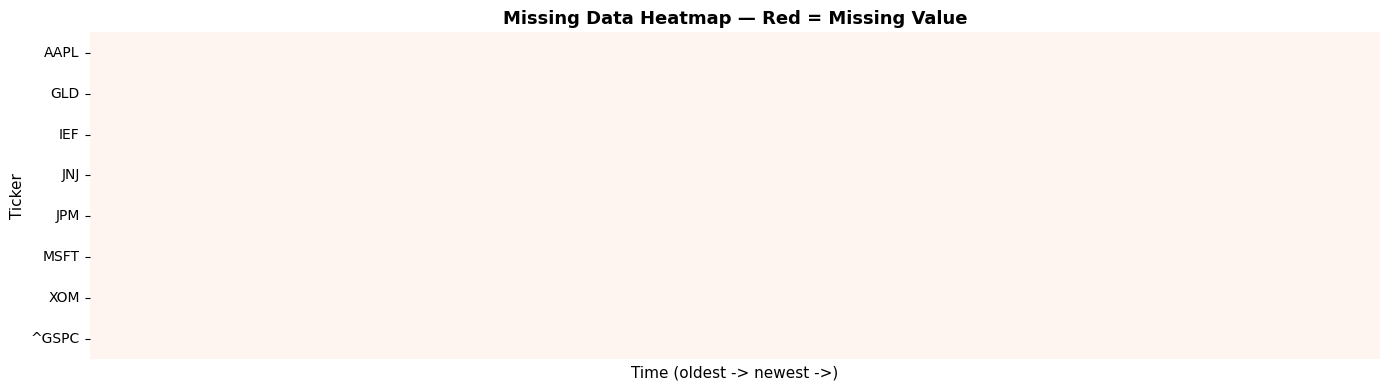

In [3]:
# ── MISSING DATA SUMMARY AND HEATMAP ─────────────────────────────────────────

# Count missing values per column
# .isnull() returns True where a value is NaN (missing), False where it is present
# .sum() adds up the Trues (True=1) to count missing rows per column
missing_counts = prices.isnull().sum()

# Compute the missing percentage: (missing / total rows) * 100
# .mean() on a boolean column gives the fraction of True values (= proportion missing)
# * 100 converts to a percentage
# .round(2) rounds to 2 decimal places
missing_pct = (
    prices
    .isnull()       # True where missing
    .mean()         # proportion of Trues = fraction missing
    .mul(100)       # convert to percentage
    .round(2)       # 2 decimal places
)

# Combine both metrics into a summary table using pd.DataFrame()
# We pass a dictionary: keys = column names, values = Series of data
missing_summary = pd.DataFrame({
    'Missing Days': missing_counts,
    'Missing (%)' : missing_pct,
})

print('=== MISSING DATA SUMMARY ===')
display(missing_summary)
print()

# ── HEATMAP ───────────────────────────────────────────────────────────────────
# A heatmap visualises missing values as a coloured grid.
# Each row = one asset (after transposing), each column = one date.
# Red cells = missing, white cells = data present.
# This is much faster to interpret than reading a table of numbers.

fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    prices.isnull().T,   # .T = transpose: flip rows and columns
                         # (assets become rows; dates become columns — easier to read)
    cmap='Reds',         # colour palette: white = present, red = missing
    cbar=False,          # no colour bar — values are binary (True/False), no scale needed
    ax=ax,               # draw on the axes we created above
    yticklabels=True,    # show ticker names on the y-axis
    xticklabels=False,   # hide individual dates on the x-axis (too many to display)
)

ax.set_title(
    'Missing Data Heatmap — Red = Missing Value',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('Time (oldest -> newest ->)', fontsize=11)
ax.set_ylabel('Ticker', fontsize=11)

plt.tight_layout()
plt.show()

## Strategy 1: Forward-Fill (ffill)

**What it does:** Carries the last known value forward to fill any gap. If Monday's price is missing, it takes Friday's price and copies it into Monday's row.

**When it is appropriate:** Equity and ETF prices on non-trading days (weekends, public holidays). The assumption is that the price was "unchanged" — which is conventionally correct for calendar-day alignment.

**The embedded assumption:** The asset's value did not change during the gap. For prices on market holidays this is a reasonable convention. For gaps caused by a trading halt (e.g. due to a corporate event), it may mask a genuine discontinuity.

**Risk:** If a gap is very long (days or weeks), forward-filling can mask genuine data quality problems. Always check the length of gaps before forward-filling blindly.

**pandas syntax:** `.ffill()` — applies forward-fill to every column simultaneously.


In [4]:
# ── FORWARD-FILL DEMO ─────────────────────────────────────────────────────────

# Find the ticker with the most missing values to use as an illustration
# .isnull().sum() = count of missing values per column
# .idxmax()       = returns the column name (ticker) with the highest count
worst_ticker = (
    prices
    .isnull()   # boolean mask
    .sum()      # count missing per column
    .idxmax()   # name of the column with the most missing values
)

print(f'Ticker with most missing values: {worst_ticker}')
print()

# .copy() creates an independent copy of the column
# Important: without .copy(), modifications would affect the original prices DataFrame
single_series = prices[worst_ticker].copy()

# Find the dates where the price is NaN (missing)
# Boolean indexing: series[condition] returns only the rows where condition is True
missing_dates = single_series[single_series.isnull()].index

if len(missing_dates) > 0:
    # Focus on a narrow window around the first missing date so the effect is visible
    first_gap = missing_dates[0]

    # .loc[start:end] selects rows by label (date) — inclusive on both ends
    # pd.Timedelta(days=5) creates a 5-day time offset for the window edges
    window = single_series.loc[
        first_gap - pd.Timedelta(days=5) :   # 5 calendar days before the gap
        first_gap + pd.Timedelta(days=5)     # 5 calendar days after the gap
    ]

    print('--- Before forward-fill (the raw data) ---')
    # .to_frame('price') converts the Series to a DataFrame with a column labelled 'price'
    print(window.to_frame('price'))

    # Apply forward-fill to the window
    # .ffill() replaces each NaN with the most recent non-NaN value above it
    window_filled = window.ffill()

    print()
    print('--- After forward-fill (.ffill()) ---')
    print(window_filled.to_frame('price'))
    print()
    print('Observation: the missing price has been replaced with the previous day\'s price.')
    print('This assumes the price was unchanged on the non-trading day.')

else:
    print(f'No missing values found in {worst_ticker} in this download window.')
    print('This can happen if the download period has no market holidays with gaps.')
    print('We still apply ffill below as a precaution — it is harmless when there are no gaps.')

# Apply forward-fill to the ENTIRE prices DataFrame (all tickers simultaneously)
# This is a single line that handles all columns at once — no loops required
prices_ffill = prices.ffill()

print()
print(f'Missing values BEFORE ffill: {prices.isnull().sum().sum()}')
print(f'Missing values AFTER  ffill: {prices_ffill.isnull().sum().sum()}')

Ticker with most missing values: AAPL

No missing values found in AAPL in this download window.
This can happen if the download period has no market holidays with gaps.
We still apply ffill below as a precaution — it is harmless when there are no gaps.

Missing values BEFORE ffill: 0
Missing values AFTER  ffill: 0


## Strategy 2: Drop (dropna)

**What it does:** Removes any row that contains at least one missing value. Every remaining row is guaranteed to have complete data for all assets.

**When it is appropriate:** When you need a balanced panel — for example, computing a correlation matrix or portfolio optimisation that requires simultaneous returns for all assets.

**Risk: survivorship bias.** If missing values are not randomly distributed across time, dropping them can distort your analysis. For example:
- If a stock tends to be halted on days of extreme volatility, dropping those days makes the portfolio look artificially calm
- If a new ETF was added to the portfolio later, all rows before its inception date are dropped — shrinking the history for all other assets

**pandas syntax:** `.dropna()` — by default drops any row with at least one NaN value.


In [5]:
# ── DROPNA DEMO ───────────────────────────────────────────────────────────────
# .dropna() removes any row that has at least one NaN value across all columns

prices_dropped = prices.dropna()

# len() counts the number of rows
rows_before = len(prices)
rows_after  = len(prices_dropped)
rows_lost   = rows_before - rows_after

print('=== DROPPING ROWS WITH ANY MISSING VALUE ===')
print(f'  Rows before dropna(): {rows_before:,}')
print(f'  Rows after  dropna(): {rows_after:,}')
print(f'  Rows lost:            {rows_lost:,}  ({rows_lost / rows_before * 100:.1f}% of the dataset)')
print()
print('Discussion:')
print('  If we use dropna(), we lose ALL rows where ANY ticker has a missing value.')
print('  For this portfolio, is that acceptable? Or does it introduce bias?')
print()
print('  Bias example: if a ticker is only missing on extreme-volatility days,')
print('  dropping those rows would make the portfolio look artificially calm.')
print()
print('  Alternative: use forward-fill first, then dropna() to handle any')
print('  remaining gaps at the very start of the series (before the first known price).')

=== DROPPING ROWS WITH ANY MISSING VALUE ===
  Rows before dropna(): 1,255
  Rows after  dropna(): 1,255
  Rows lost:            0  (0.0% of the dataset)

Discussion:
  If we use dropna(), we lose ALL rows where ANY ticker has a missing value.
  For this portfolio, is that acceptable? Or does it introduce bias?

  Bias example: if a ticker is only missing on extreme-volatility days,
  dropping those rows would make the portfolio look artificially calm.

  Alternative: use forward-fill first, then dropna() to handle any
  remaining gaps at the very start of the series (before the first known price).


## Strategy 3: Interpolate

**What it does:** Estimates a value between two known data points by drawing a straight line between them (linear interpolation). For example, if CPI was 310.0 in January and 312.0 in February, the interpolated value for January 15th would be approximately 311.0.

**When it is appropriate:** Smooth, slowly changing macro series like CPI or GDP, where you need to align a monthly series to daily frequency. The interpolated values are estimates, but they are far more useful than leaving 29 out of every 30 days as blank.

**When it is dangerous:** Equity prices. Interpolating stock prices invents prices that never existed in the market. This would create fake, artificially smooth price histories that produce wrong return calculations and misleadingly low volatility estimates.

**The rule of thumb:** Interpolate macro series; forward-fill or drop equity prices.

**pandas syntax:** `.interpolate(method='linear')` — fills gaps using linear interpolation.


In [6]:
# ── INTERPOLATE DEMO ON CPI ────────────────────────────────────────────────────
# Interpolation is most appropriate for smooth macro series like CPI.
# The idea: if CPI was 310 in January and 312 in February,
# we estimate intermediate daily values (310.06, 310.13, ...) by drawing a straight line.
# This is only an estimate — but far better than leaving 29 out of 30 days blank.

print('=== RAW CPI SERIES (monthly frequency) ===')
print(f'Total rows: {cpi.shape[0]}')
print()
# .to_frame('CPI') converts the Series to a DataFrame for cleaner display formatting
display(cpi.to_frame('CPI').head(8))

# ── STEP 1: Create a daily date index matching our equity price range ───────────
# pd.date_range() generates a sequence of dates at a given frequency
# freq='D' = daily frequency (every calendar day, including weekends)
daily_index = pd.date_range(
    start = prices.index.min(),   # first date in our equity price data
    end   = prices.index.max(),   # last date in our equity price data
    freq  = 'D',                  # one entry per calendar day
)

# ── STEP 2: Reindex the monthly CPI series to the daily index ──────────────────
# .reindex() expands the Series to include all dates in daily_index.
# Dates that were not in the original monthly CPI series become NaN.
# Result: a daily Series where only the first day of each reported month has a value;
# all other days are NaN.
cpi_daily_raw = (
    cpi
    .reindex(daily_index)   # expand to daily frequency; non-month-start dates become NaN
)

print()
print('=== CPI REINDEXED TO DAILY (before interpolation) ===')
print(f'Total rows:       {cpi_daily_raw.shape[0]}')
print(f'Non-missing rows: {cpi_daily_raw.notna().sum()}')
print(f'Missing rows:     {cpi_daily_raw.isna().sum()}')
print()
display(cpi_daily_raw.to_frame('CPI').head(10))

# ── STEP 3: Interpolate to fill the daily gaps ──────────────────────────────────
# .interpolate(method='linear') fills each NaN by drawing a straight line
# between the two surrounding known values.
# This gives us an estimated CPI value for every single calendar day.
cpi_daily_interpolated = (
    cpi_daily_raw
    .interpolate(method='linear')   # fill gaps by linear interpolation
)

print()
print('=== CPI AFTER LINEAR INTERPOLATION ===')
display(cpi_daily_interpolated.to_frame('CPI').head(10))
print()
print('Each day now has a CPI estimate — ready to merge with daily equity data.')

=== RAW CPI SERIES (monthly frequency) ===


NameError: name 'cpi' is not defined

---

### Discussion: Choosing the Right Missing-Data Strategy

> **For each of the three missing-data strategies we just saw:**
>
> 1. **Forward-fill** — what investment assumption does it embed? Is that assumption always valid?
> 2. **Drop** — what type of bias could it introduce into portfolio analysis?
> 3. **Interpolate** — when is it appropriate, and when would it be dangerous to use on equity prices?
>
> There is no single correct answer. The right choice depends on the data and the analysis. The important thing is to make the choice **consciously** and be able to explain it to a colleague or a client.
>
> *Pairs discussion — 5 minutes.*


---

# Section 2 — Frequency Alignment

## The daily-vs-monthly mismatch

Our two data sources operate on different time frequencies:

| Data source | Frequency | Rows over 3 years |
|---|---|---|
| Equity prices (yfinance) | Daily (trading days only) | ~756 |
| CPI (FRED) | Monthly | ~36 |

If we try to join these two datasets directly, 19 out of every 20 rows in the merged table will have a blank CPI value — because CPI is only reported once per month, not every day.

The next cell shows what this naive merge looks like. Then we show the correct approach: **resample** the daily equity prices to monthly frequency so both datasets share the same time axis.

**Resampling** is the process of changing the frequency of a time series:
- **Downsampling** (what we do here): aggregate daily data into monthly buckets. For prices, we keep the last value in each monthly bucket — the closing price on the last trading day of the month.
- **Upsampling**: expand lower-frequency data to higher frequency (e.g. interpolating monthly CPI to daily — which we did in the previous section).


In [7]:
# ── NAIVE MERGE: SHOWING THE FREQUENCY MISMATCH PROBLEM ─────────────────────
# To demonstrate the problem, we attempt a direct merge of daily prices with monthly CPI.
# A 'left' merge keeps all rows from the left DataFrame (daily prices)
# and tries to find matching rows in the right DataFrame (monthly CPI).
# When no match exists (most days), the CPI column will be NaN.

naive_merge = (
    prices[['AAPL']]          # use just one equity column to keep output readable
    .merge(
        cpi.to_frame('CPI'),  # CPI as a DataFrame (merge requires DataFrame, not Series)
        how         = 'left', # keep all rows from the left (daily) DataFrame
        left_index  = True,   # match rows using the left DataFrame's date index
        right_index = True,   # match rows using the right DataFrame's date index
    )
)

print('=== NAIVE MERGE: AAPL (daily) joined with CPI (monthly) ===')
print(f'Total rows: {len(naive_merge):,}')
print(f'CPI is populated on {naive_merge["CPI"].notna().sum()} out of {len(naive_merge):,} rows.')
print(f'CPI is missing  on {naive_merge["CPI"].isna().sum():,} rows.')
print()
display(naive_merge.head(15))
print()
print('Problem: CPI has a value only on the first day of each reported month.')
print('On all other days it is NaN — useless for analysis requiring aligned series.')
print()
print('Solution: resample equity prices to MONTHLY frequency to match CPI.')

NameError: name 'cpi' is not defined

In [8]:
# ── RESAMPLE DAILY EQUITY PRICES TO MONTHLY ───────────────────────────────────
# .resample('ME') groups the daily rows into monthly buckets.
#   'ME' = Month End (the bucket label is the last calendar day of each month)
# .last() keeps only the last row in each bucket = the last trading day's price.
# This is the standard convention: use the last available price of each month.

prices_monthly = (
    prices              # daily DataFrame: ~756 rows
    .resample('ME')     # group rows into monthly buckets, labelled by month-end date
    .last()             # from each monthly bucket, keep the last row (last trading day's price)
)

print('=== RESAMPLING: Daily -> Monthly ===')
print(f'  Daily prices:   {len(prices):,} rows')
print(f'  Monthly prices: {len(prices_monthly):,} rows')
print()
print('Each row now represents the last trading day of a calendar month.')
print('This is the standard end-of-month price convention used in performance reporting.')
print()
display(prices_monthly.head(8))

=== RESAMPLING: Daily -> Monthly ===
  Daily prices:   1,255 rows
  Monthly prices: 61 rows

Each row now represents the last trading day of a calendar month.
This is the standard end-of-month price convention used in performance reporting.



Ticker,AAPL,GLD,IEF,JNJ,JPM,MSFT,XOM,^GSPC
Date,,,,,,,,
2021-04-30,128.041458,165.660004,99.380493,141.311859,135.553223,241.981720,47.262291,4181.169922
2021-05-31,121.575737,178.380005,99.802750,147.890701,144.745193,240.136017,48.897423,4204.109863
2021-06-30,133.625031,165.630005,100.823288,143.949844,137.077835,260.544891,52.843063,4297.500000
2021-07-31,142.308304,169.820007,102.829910,150.468399,134.534988,274.019379,48.227242,4395.259766
2021-08-31,148.354874,169.690002,102.424294,152.180023,141.776718,290.896545,46.363506,4522.680176
2021-09-30,138.261307,164.220001,100.788521,141.957275,145.091812,271.662781,50.020199,4307.540039
2021-10-31,146.371338,166.649994,100.342094,143.170319,151.494751,319.554565,54.824928,4605.379883
2021-11-30,161.752319,165.500000,101.437920,137.959091,141.632324,319.144775,51.571491,4567.000000


In [ ]:
# ── CLEAN MERGE: MONTHLY EQUITY + MONTHLY CPI ─────────────────────────────────
# Now both datasets are at monthly frequency — they share the same time axis.
# A clean merge should produce a complete row for every month with no NaN gaps.

combined_monthly = (
    prices_monthly               # monthly equity prices (resampled)
    .merge(
        cpi.to_frame('CPI'),     # monthly CPI Series as a DataFrame
        how         = 'inner',   # 'inner' = keep only months present in BOTH datasets
        left_index  = True,      # match on the monthly equity index
        right_index = True,      # match on the CPI index
    )
)

print('=== CLEAN MERGE: Monthly equity + Monthly CPI ===')
print(f'Rows:    {len(combined_monthly)}')
print(f'Columns: {list(combined_monthly.columns)}')
print()
print(f'Missing values after merge: {combined_monthly.isnull().sum().sum()}')
print('(Should be 0 — every month has complete data for all assets and CPI)')
print()
display(combined_monthly.head(8))
print()
print('The frequency mismatch is resolved. Both equity prices and CPI now share')
print('the same monthly time axis and can be used in the same analysis.')

---

# Section 3 — Returns Calculations

## Why we use returns, not prices

Raw prices are **not comparable** across assets:
- Apple trades at ~$185 and GLD at ~$175 — do they have the same economic exposure? Of course not. The price level tells you nothing about performance.
- A price drop from $200 to $190 (-5%) is very different from a drop from $50 to $40 (-20%), even though both lose $10.

**Returns** normalise this: they express gain or loss as a proportion of the starting price. This makes every asset comparable, regardless of its price level.

## Simple return vs. log return

**Simple return:** The percentage change from one period to the next.
> Formula: `(P₁ - P₀) / P₀` = `(P₁ / P₀) - 1`
> Best for: single-period reporting, client communication ("AAPL was up 3.2% in January")

**Log return** (natural logarithm of the price ratio): `ln(P₁ / P₀)`
> Key property: **additive across time**. If an asset returns +5% in Jan and -3% in Feb:
> - Simple compounding: `(1.05)(0.97) - 1 = 1.85%` — requires multiplication
> - Log returns: `0.0488 + (-0.0305) = 0.0183` — simple addition
>
> This additivity makes log returns mathematically superior for statistical analysis, volatility calculation, and portfolio construction.

**In practice:** Use log returns for volatility, correlation, and portfolio analytics. Use simple returns for client reports and performance attribution.


In [9]:
# ── SIMPLE PERCENTAGE RETURNS ─────────────────────────────────────────────────
# .pct_change() computes (P_t - P_{t-1}) / P_{t-1} for every column simultaneously.
# This is the percentage return from one period to the next.
# The first row will always be NaN — there is no prior price to compare against.
# .dropna() removes that first NaN row.

returns_simple = (
    prices_monthly   # monthly end-of-month prices
    .pct_change()    # (P_t - P_{t-1}) / P_{t-1} for every column
    .dropna()        # remove the first row (it is always NaN — no prior month to compare to)
)

print('=== SIMPLE MONTHLY RETURNS ===')
print(f'Shape: {returns_simple.shape[0]} months x {returns_simple.shape[1]} assets')
print()
print('First 5 rows (each cell = that asset\'s return in that calendar month):')
display(
    returns_simple
    .head()
    .style.format('{:.2%}')   # display as percentage with 2 decimal places
)
print()
print(f'Typical monthly return range: {returns_simple.min().min():.1%} to {returns_simple.max().max():.1%}')

=== SIMPLE MONTHLY RETURNS ===
Shape: 60 months x 8 assets

First 5 rows (each cell = that asset's return in that calendar month):


AttributeError: The '.style' accessor requires jinja2

In [ ]:
# ── LOG RETURNS ───────────────────────────────────────────────────────────────
# Log return formula: ln(P_t / P_{t-1}) = ln(P_t) - ln(P_{t-1})
# We compute this in two steps:
#   1. Take the natural log of every price: np.log(price)
#   2. Take the first difference of the log prices: log(P_t) - log(P_{t-1}) = .diff()
#
# Key property: log returns are ADDITIVE across time.
# This means annual log return = sum of 12 monthly log returns (no multiplication needed).
# This additivity is why log returns are the standard for statistical analysis.

returns_log = (
    prices_monthly           # monthly end-of-month prices
    .apply(np.log)           # apply natural log to every element in the DataFrame
    .diff()                  # .diff() = current row minus previous row
                             # = log(P_t) - log(P_{t-1}) = log return
    .dropna()                # remove the first row (NaN — no prior row to subtract)
)

print('=== LOG MONTHLY RETURNS ===')
print(f'Shape: {returns_log.shape}')
print()

# Compare simple vs log return for AAPL to show they are very close for small moves
print('Comparing simple vs log return for AAPL (first 5 months):')
comparison = pd.DataFrame({
    'AAPL Simple Return': returns_simple['AAPL'].head(),
    'AAPL Log Return'   : returns_log['AAPL'].head(),
})


pd.options.display.float_format = '{:.4f}'.format; print(comparison.head())

print()
print('Note: for small returns (< 5%) simple and log returns are nearly identical.')
print('The difference matters most for large moves (crashes, big rallies).')
print('For a -30% monthly return: simple = -0.3000, log = -0.3567 (materially different).')

=== LOG MONTHLY RETURNS ===
Shape: (60, 8)

Comparing simple vs log return for AAPL (first 5 months):
            AAPL Simple Return  AAPL Log Return
Date                                           
2021-05-31             -0.0505          -0.0518
2021-06-30              0.0991           0.0945
2021-07-31              0.0650           0.0630
2021-08-31              0.0425           0.0416
2021-09-30             -0.0680          -0.0705

Note: for small returns (< 5%) simple and log returns are nearly identical.
The difference matters most for large moves (crashes, big rallies).
For a -30% monthly return: simple = -0.3000, log = -0.3567 (materially different).


In [ ]:
# ── ROLLING 20-DAY ANNUALISED VOLATILITY ──────────────────────────────────────
# Rolling volatility measures how much an asset's returns vary over a moving window.
# A 20-day window = approximately one trading month.
# Each point on the chart = the annualised volatility over the PAST 20 trading days.
# This is the primary input to most risk management models and options pricing.
#
# We use DAILY returns here (not monthly) because:
# 1. Daily data gives 252+ data points per year — enough to estimate volatility reliably
# 2. Monthly data only gives 12 points per year — a rolling 20-month window would be too long

# Step 1: Compute daily simple returns from the original daily price data
returns_daily = (
    prices          # daily price DataFrame
    .pct_change()   # daily percentage change
    .dropna()       # remove the first row (always NaN)
)

# Step 2: Compute the rolling 20-day standard deviation, then annualise
# .rolling(window=20) creates a sliding window of 20 rows
# .std()              computes the standard deviation within each window
# .mul(np.sqrt(252))  annualises: multiply daily sigma by sqrt(252)
#   Why sqrt(252)? Standard deviation scales with the square root of time.
#   252 trading days per year => sigma_annual = sigma_daily * sqrt(252)
rolling_vol = (
    returns_daily
    .rolling(window=20)     # sliding 20-trading-day window
    .std()                  # standard deviation of daily returns within the window
    .mul(np.sqrt(252))      # annualise by multiplying by sqrt(252)
    .dropna()               # first 19 rows are NaN (not enough data to fill a 20-day window)
)

print('=== ROLLING 20-DAY ANNUALISED VOLATILITY ===')
print(f'Shape: {rolling_vol.shape}')
print()
print('Latest volatility readings (most recent date in the dataset):')

latest_vol = rolling_vol.iloc[-1].to_frame('Annualised Vol').map(lambda x: f'{x:.1%}')
print(latest_vol)



=== ROLLING 20-DAY ANNUALISED VOLATILITY ===
Shape: (1235, 8)

Latest volatility readings (most recent date in the dataset):
       Annualised Vol
Ticker               
AAPL            21.0%
GLD             36.9%
IEF              6.8%
JNJ             13.6%
JPM             20.8%
MSFT            21.7%
XOM             29.5%
^GSPC           18.1%


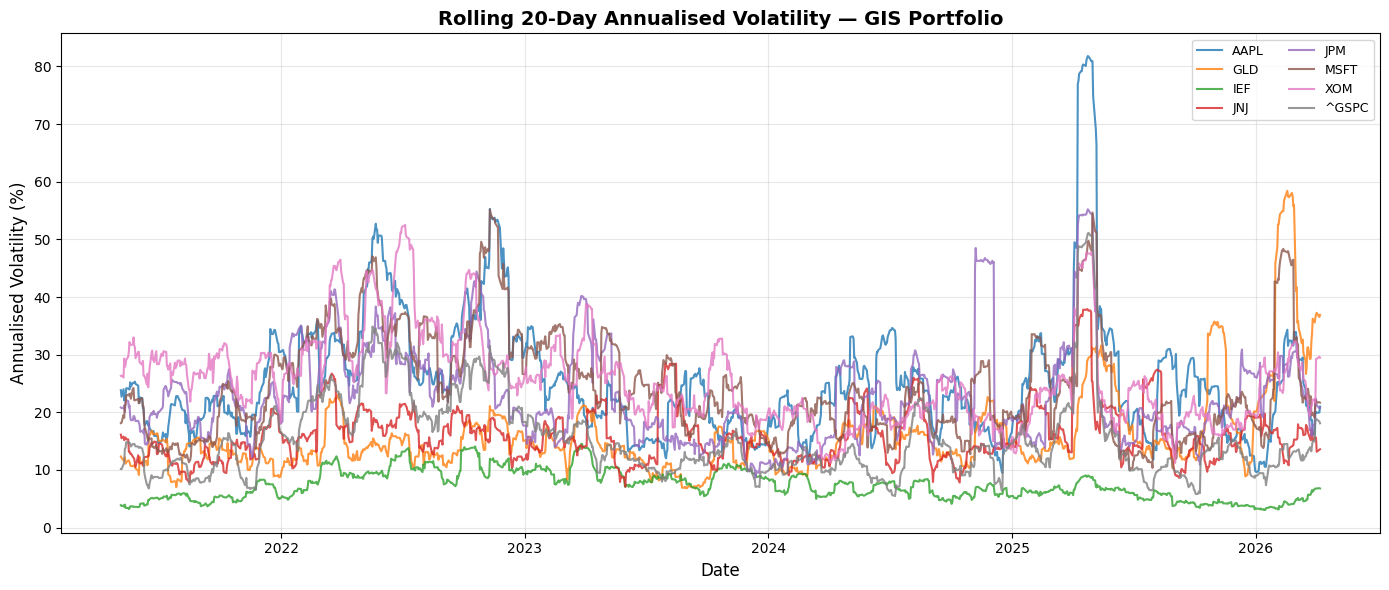


Discussion: Which asset is consistently the most volatile?
            Which is the most stable (lowest, flattest line)?
            When did volatility spike across the whole portfolio?
            What market event coincides with that spike?


In [20]:
# ── PLOT ROLLING VOLATILITY ───────────────────────────────────────────────────
# A line chart of rolling volatility over time shows:
#   - Which assets are consistently more or less volatile
#   - When market-wide stress events caused volatility to spike across the portfolio
#   - Whether volatility has been rising or falling in recent months

fig, ax = plt.subplots(figsize=(14, 6))

# Loop through all tickers and plot each as a separate line
# alpha=0.8 makes lines slightly transparent so overlapping lines are still visible
for ticker in rolling_vol.columns:
    ax.plot(
        rolling_vol.index,             # x-axis: date
        rolling_vol[ticker] * 100,     # y-axis: volatility as a percentage (not decimal)
        label=ticker,                  # legend entry for this line
        linewidth=1.5,                 # line thickness
        alpha=0.8,                     # slight transparency
    )

ax.set_title(
    'Rolling 20-Day Annualised Volatility — GIS Portfolio',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Date',                       fontsize=12)
ax.set_ylabel('Annualised Volatility (%)',  fontsize=12)

# Place the legend in the top-right corner; use 2 columns to save vertical space
ax.legend(
    loc='upper right',
    fontsize=9,
    ncol=2,
)

# Faint gridlines improve readability without cluttering the chart
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('Discussion: Which asset is consistently the most volatile?')
print('            Which is the most stable (lowest, flattest line)?')
print('            When did volatility spike across the whole portfolio?')
print('            What market event coincides with that spike?')

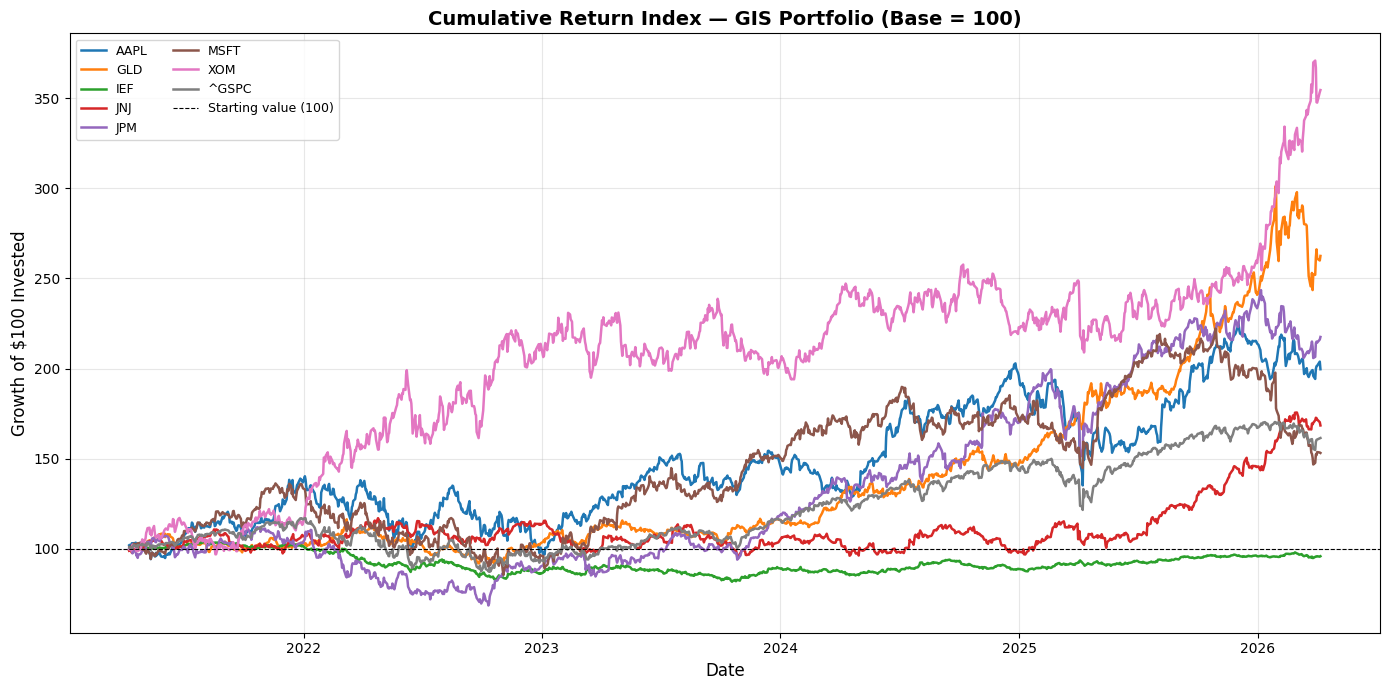


Discussion: Which asset has grown the most over this period?
            Which has been the most stable (least volatile line)?
            Does the ranking match your intuition?


In [21]:
# ── CUMULATIVE RETURN INDEX ───────────────────────────────────────────────────
# A cumulative return index starts every asset at 100 on the first day
# and compounds its daily returns forward from there.
#
# This is the correct way to compare performance across assets with different price levels:
#   AAPL at $185 and GLD at $175 — the price levels are nearly the same but tell us nothing
#   about which performed better over the last 3 years.
#   Starting both at 100 and tracking growth makes the comparison honest.
#
# Formula: index_t = 100 x (1+r_1) x (1+r_2) x ... x (1+r_t)
# In pandas: (1 + returns).cumprod() computes this product cumulatively.

cumulative_returns = (
    (1 + returns_daily)   # convert each return to a growth factor: +2% -> 1.02, -3% -> 0.97
    .cumprod()            # multiply all growth factors cumulatively: each row = all prior rows multiplied
    .mul(100)             # scale so the starting value is 100 (easier to read)
)

# Plot all assets on one chart
fig, ax = plt.subplots(figsize=(14, 7))

for ticker in cumulative_returns.columns:
    ax.plot(
        cumulative_returns.index,
        cumulative_returns[ticker],
        label=ticker,
        linewidth=1.8,
    )

# Reference line at 100 (the starting value) — everything above = positive return
ax.axhline(
    100,
    color='black',
    linewidth=0.8,
    linestyle='--',
    label='Starting value (100)',
)

ax.set_title(
    'Cumulative Return Index — GIS Portfolio (Base = 100)',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Growth of $100 Invested', fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('Discussion: Which asset has grown the most over this period?')
print('            Which has been the most stable (least volatile line)?')
print('            Does the ranking match your intuition?')

=== SUMMARY STATISTICS — MONTHLY RETURNS ===


,Mean Monthly Return,Std Dev (Monthly),Annualised Return,Annualised Volatility,Min Monthly Return,Max Monthly Return,Skewness
Ticker,,,,,,,
AAPL,0.0138,0.0700,0.1658,0.2424,-0.1223,0.1886,0.1594
GLD,0.0171,0.0462,0.2055,0.1601,-0.1105,0.1227,0.0675
IEF,-0.0005,0.0219,-0.0056,0.0760,-0.0473,0.0455,-0.0891
JNJ,0.0099,0.0495,0.1193,0.1716,-0.0860,0.1025,0.1676
JPM,0.0154,0.0680,0.1850,0.2355,-0.1484,0.2154,0.1537
MSFT,0.0094,0.0677,0.1129,0.2345,-0.1103,0.1763,0.3959
XOM,0.0237,0.0765,0.2842,0.2649,-0.1291,0.2692,0.6994
^GSPC,0.0086,0.0436,0.1034,0.1512,-0.0934,0.0911,-0.3941


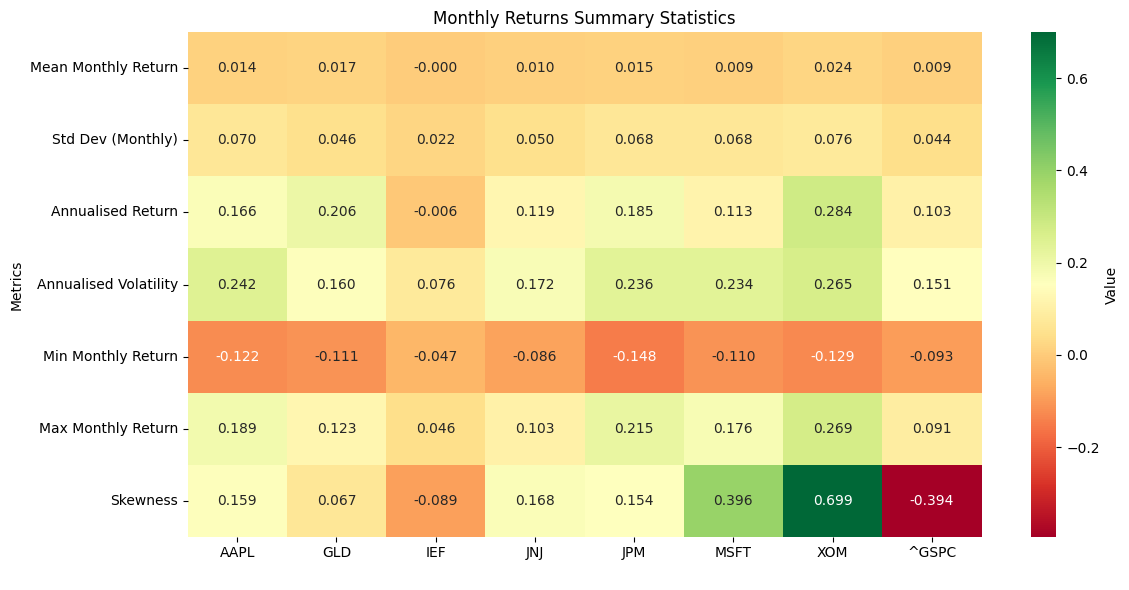


What does a negative mean return + high volatility tell you?
  -> The asset has been a drag on portfolio performance AND added significant risk.
  -> This combination is the worst outcome for a risk-adjusted portfolio.

What does a strongly negative skewness tell you?
  -> The asset has more large negative returns than large positive returns.
  -> Think of it as: the bad days are worse than the good days are good.


In [30]:
# ── SUMMARY STATISTICS TABLE ──────────────────────────────────────────────────
# A summary statistics table gives a quick snapshot of each asset's performance profile.
# We use MONTHLY returns because monthly removes some daily noise
# and is the standard frequency for investment performance reporting.
#
# Skewness measures the asymmetry of the return distribution:
#   Skewness = 0: symmetric (like a normal distribution)
#   Negative skew: more extreme negative returns than positive — 'fat left tail'
#   Positive skew: more extreme positive returns than negative — 'fat right tail'
# For equity investments, negative skew means larger drawdowns than rallies.

summary_stats = pd.DataFrame({
    'Mean Monthly Return'   : returns_simple.mean(),              # average monthly return
    'Std Dev (Monthly)'     : returns_simple.std(),               # monthly volatility
    'Annualised Return'     : returns_simple.mean() * 12,         # scale mean to annual (x12)
    'Annualised Volatility' : returns_simple.std() * np.sqrt(12), # annualise std dev (x sqrt(12))
    'Min Monthly Return'    : returns_simple.min(),               # worst single month
    'Max Monthly Return'    : returns_simple.max(),               # best single month
    'Skewness'              : returns_simple.skew(),              # asymmetry of the distribution
})


import seaborn as sns
import matplotlib.pyplot as plt

print('=== SUMMARY STATISTICS — MONTHLY RETURNS ===')
display(summary_stats)  # Inspect structure first

plt.figure(figsize=(12, 6))
sns.heatmap(
    summary_stats.T, 
    annot=True, 
    fmt='.3f',  # Safer numeric fmt; multiply by 100 if needed
    cmap='RdYlGn', 
    square=False,
    cbar_kws={'label': 'Value'}
)
plt.title('Monthly Returns Summary Statistics')
plt.ylabel('Metrics')
plt.xlabel(' ')
plt.tight_layout()
plt.show()

print()
print('What does a negative mean return + high volatility tell you?')
print('  -> The asset has been a drag on portfolio performance AND added significant risk.')
print('  -> This combination is the worst outcome for a risk-adjusted portfolio.')
print()
print('What does a strongly negative skewness tell you?')
print('  -> The asset has more large negative returns than large positive returns.')
print('  -> Think of it as: the bad days are worse than the good days are good.')

---

### Reflection Prompt

> **"How does this summary table compare to how you currently assess performance across your coverage universe?"**
>
> - What would it take to produce this table from scratch in Excel — and how long would it take?
> - What could you do with 5 minutes and this output that you currently cannot do efficiently?
> - What additional statistics would you want to add — and can you guess how?
>
> *Individual reflection — 3 minutes, then brief group share.*


---

# Section 4 — The Returns Matrix

## What is the returns matrix?

The **returns matrix** is a DataFrame where:
- **Rows** = time periods (months, in our case)
- **Columns** = portfolio holdings (assets)
- **Each cell** = that asset's return in that period

It is the single most important data object in quantitative portfolio analysis. Virtually every calculation in Day 2 — Sharpe ratios, correlation matrices, maximum drawdown, Value at Risk, Monte Carlo simulation — takes the returns matrix as its starting point.

**Understanding its structure is more important than knowing how to build it.** Once you can read a returns matrix and understand what each row and column represents, the analytics on top of it become intuitive.

**One important distinction:** We exclude `^GSPC` (the S&P 500 Index) from the returns matrix, because it is our **benchmark** — not a portfolio holding. We keep it separately as `benchmark_returns` for comparison in later sessions.


In [32]:
# ── BUILD THE MONTHLY RETURNS MATRIX ─────────────────────────────────────────
# The returns matrix uses log returns of the portfolio HOLDINGS
# (log returns are preferred for statistical analysis — see Section 3 above).
# We exclude ^GSPC (benchmark) from the holdings matrix.

# Define the portfolio holding tickers (excluding the benchmark ^GSPC)
PORTFOLIO_TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'GLD', 'IEF']

# Select only the portfolio holding columns from the log returns DataFrame
# .dropna() removes any remaining NaN rows to ensure a clean, complete matrix
returns_matrix = (
    returns_log[PORTFOLIO_TICKERS]   # select only the 7 portfolio holding columns
    .dropna()                        # remove any rows that still have NaN values
)

# Keep the benchmark (^GSPC) separately for performance comparison in later sessions
# Double brackets [[...]] return a DataFrame (single column) instead of a Series
benchmark_returns = (
    returns_log[['^GSPC']]   # extract S&P 500 as a single-column DataFrame
    .dropna()
)

print('=== RETURNS MATRIX ===')
print(f'Shape: {returns_matrix.shape[0]} months x {returns_matrix.shape[1]} assets')
print(f'Date range: {returns_matrix.index[0].date()}  ->  {returns_matrix.index[-1].date()}')
print()
print('First 5 rows:')


display(returns_matrix.head().round(3))


print()
print('This returns_matrix object is the input to:')
print('  -> Portfolio construction and optimisation (Session 3)')
print('  -> Correlation and covariance analysis (Session 3)')
print('  -> Value at Risk and Monte Carlo simulation (Session 3)')
print()
print(f'Benchmark returns (^GSPC): {benchmark_returns.shape[0]} months')

=== RETURNS MATRIX ===
Shape: 60 months x 7 assets
Date range: 2021-05-31  ->  2026-04-30

First 5 rows:


Ticker,AAPL,MSFT,JPM,XOM,JNJ,GLD,IEF
Date,,,,,,,
2021-05-31,-0.0520,-0.0080,0.0660,0.0340,0.0460,0.0740,0.0040
2021-06-30,0.0950,0.0820,-0.0540,0.0780,-0.0270,-0.0740,0.0100
2021-07-31,0.0630,0.0500,-0.0190,-0.0910,0.0440,0.0250,0.0200
2021-08-31,0.0420,0.0600,0.0520,-0.0390,0.0110,-0.0010,-0.0040
2021-09-30,-0.0700,-0.0680,0.0230,0.0760,-0.0700,-0.0330,-0.0160



This returns_matrix object is the input to:
  -> Portfolio construction and optimisation (Session 3)
  -> Correlation and covariance analysis (Session 3)
  -> Value at Risk and Monte Carlo simulation (Session 3)

Benchmark returns (^GSPC): 60 months


In [33]:
# ── VALIDATE THE RETURNS MATRIX ───────────────────────────────────────────────
# Before moving to any analysis, always validate the output of a data pipeline.
# These five checks ensure the returns matrix is clean and ready for Day 2.

print('=== RETURNS MATRIX VALIDATION ===')
print()

# Check 1: shape
print(f'1. Shape:           {returns_matrix.shape[0]} months x {returns_matrix.shape[1]} assets')

# Check 2: missing values (should be zero after our cleaning steps)
missing_count = returns_matrix.isnull().sum().sum()   # .sum().sum() = sum across all rows and columns
missing_flag  = 'OK' if missing_count == 0 else 'PROBLEM — inspect for NaN values'
print(f'2. Missing values:  {missing_count}  ({missing_flag})')

# Check 3: column names (confirm the right tickers are present)
print(f'3. Columns:         {list(returns_matrix.columns)}')

# Check 4: return range (a monthly return outside -50% / +50% for these assets would be suspicious)
min_return = returns_matrix.min().min()
max_return = returns_matrix.max().max()
print(f'4. Return range:    {min_return:.2%}  to  {max_return:.2%}')
print(f'   (A monthly return outside -50% / +50% for these assets would be suspicious)')

# Check 5: benchmark shape
print(f'5. Benchmark shape: {benchmark_returns.shape}  (^GSPC monthly log returns)')

print()
print('All checks passed. The returns matrix is ready for Session 3.')

=== RETURNS MATRIX VALIDATION ===

1. Shape:           60 months x 7 assets
2. Missing values:  0  (OK)
3. Columns:         ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'GLD', 'IEF']
4. Return range:    -16.06%  to  23.84%
   (A monthly return outside -50% / +50% for these assets would be suspicious)
5. Benchmark shape: (60, 1)  (^GSPC monthly log returns)

All checks passed. The returns matrix is ready for Session 3.


In [ ]:
# ─── OPTIONAL: Save outputs to CSV for Excel inspection ───────────────────────
# These files are NOT needed by any other notebook.
# Save only if you want to inspect the data in Excel or share it.

# The monthly returns matrix — the primary output of this session
returns_matrix.to_csv('returns_matrix.csv')

# The benchmark returns separately
benchmark_returns.to_csv('benchmark_returns.csv')

# The cumulative return index (base 100, daily) — useful for charting in Excel
cumulative_returns.to_csv('cumulative_returns.csv')

# The summary statistics table
summary_stats.to_csv('summary_stats.csv')

print('Saved (optional):')
print('  returns_matrix.csv       — monthly log returns for 7 portfolio holdings')
print('  benchmark_returns.csv    — monthly log returns for ^GSPC benchmark')
print('  cumulative_returns.csv   — cumulative return index (base 100, daily)')
print('  summary_stats.csv        — mean, volatility, min, max, skewness per asset')
print()
print('Download from: Files panel (left sidebar) -> right-click file -> Download')

---

## Session 2 Debrief

### What to take away from Session 2:

- **Raw financial data is never analysis-ready.** Missing values, frequency mismatches, and inconsistent formatting are the rule, not the exception — in Python just as in Bloomberg or Excel.
- **There is no single correct way to handle missing data.** Forward-fill, drop, and interpolate each embed different assumptions. The important thing is to choose consciously and document your choice.
- **The returns matrix is the central data object of this seminar:** rows = months, columns = assets, cells = log returns. You now have one — clean, validated, and ready for portfolio analytics.

---

### Outputs you built today:

| Output | Description |
|---|---|
| `prices_ffill` | Forward-filled daily price series (no missing values) |
| `prices_monthly` | End-of-month prices (daily → monthly resampling) |
| `combined_monthly` | Monthly equity prices + CPI (frequency-aligned merge) |
| `returns_simple` | Monthly simple percentage returns for all 8 assets |
| `returns_log` | Monthly log returns for all 8 assets |
| `rolling_vol` | Rolling 20-day annualised volatility (daily) |
| `cumulative_returns` | Cumulative return index (base 100, daily) |
| `summary_stats` | Mean, volatility, min, max, skewness per asset |
| `returns_matrix` | Monthly log returns for 7 portfolio holdings (ready for Day 2) |
| `benchmark_returns` | Monthly log returns for ^GSPC benchmark |

---

### Preview of Day 2 (tomorrow morning):

> **"Is this portfolio earning adequate return for the risk it is taking?"**
>
> Using the `returns_matrix` you just built, Session 3 will compute:
> - Sharpe ratios (return per unit of risk)
> - Correlation matrices and heatmaps
> - Maximum drawdown
> - Value at Risk (historical and parametric)
> - Monte Carlo portfolio simulations
>
> All from code that is already written — your job is to read the outputs and form investment judgements.
